# PCA factor model of vol surface moves

The book's vega is bucketed onto a fixed pillar grid (8 TTMs × 13 moneyness) via its
linear-interpolation weights — exact, so `bucket_vega · Δσ` reproduces the per-option
linear vol P&L to machine precision. PCA is fit on daily pillar-vol changes **weighted
by the book's average absolute dollar vega per pillar**, so factor capacity is allocated
by P&L relevance rather than raw surface variance (far-OTM short-dated smile noise the
book barely prices off is ignored).

- Exposure to factor k: \$E_k = (\text{bucket vega}/w)\cdot L_k\$
- Daily factor movement (score): \$f_k = L_k\cdot((\Delta\sigma-\mu)\circ w)\$
- Vega P&L estimate with K factors: \$\text{bucket vega}\cdot\mu + \sum_{k\le K}E_k f_k\$

This notebook illustrates the factor shapes, their history, the quality of the factor
estimate vs full per-option revaluation, and reconciles the PCA vega target with the
`vol` component of the attribution notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from vol_pca import load_surfaces, simulate_book, fit_pca, factor_vega_estimates, estimate_metrics
from vol_pca.attribution import independent_attribution
from vol_pca.surface import TTM_PILLARS, MONEYNESS

PC_C = ["#2a78d6", "#eb6834", "#1baf7a"]          # PC1/2/3 (all-pairs safe trio)
INK, MUT = "#0b0b0b", "#898781"
DIV_CMAP = LinearSegmentedColormap.from_list("bwr_soft", ["#2a78d6", "#f0efec", "#e34948"])
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})
TTM_LBL = ["1M", "2M", "3M", "4M", "6M", "8M", "10M", "12M"]
MON_LBL = [str(int(m)) for m in MONEYNESS]

sd = load_surfaces("SPX_volSurface 2.csv")
book, bucket_vega, dsigma = simulate_book(sd)
attr, _ = independent_attribution(sd)
normal = (book["gap_days"] <= 7).to_numpy()

vega_w = np.abs(bucket_vega[normal]).mean(axis=0)
model = fit_pca(dsigma, fit_mask=normal, weights=vega_w)

# sign convention: the largest-|loading| pillar of each factor is positive
for i in range(6):
    pat = model.components[i] / model.weights
    if pat[np.argmax(np.abs(pat))] < 0:
        model.components[i] *= -1

ks = [1, 2, 3, 5, 10, model.n_components]
estimates, exposures, scores = factor_vega_estimates(bucket_vega, dsigma, model, ks)
target = book["pl_vega_full"].to_numpy()
print(f"{len(book)} P&L days; grid {len(TTM_PILLARS)} TTMs x {len(MONEYNESS)} moneyness "
      f"= {dsigma.shape[1]} pillars")

3140 P&L days; grid 8 TTMs x 13 moneyness = 104 pillars


## Factor shapes

Each panel shows the surface move produced by a **+1 standard deviation** move of that
factor, in vol points, on the TTM × moneyness grid. PC1 is the level factor (all vols up,
short end most), PC2/PC3 reshape the term structure and skew.

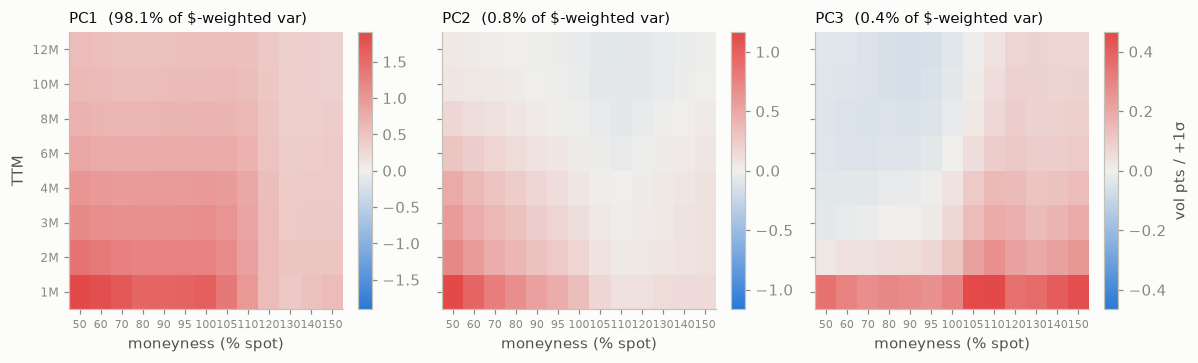

In [2]:
nt, nm = len(TTM_PILLARS), len(MONEYNESS)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
for i, ax in enumerate(axes):
    pat = (scores[normal][:, i].std() * model.components[i] / model.weights * 100).reshape(nt, nm)
    vmax = np.abs(pat).max()
    im = ax.imshow(pat, origin="lower", aspect="auto", cmap=DIV_CMAP, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(nm), MON_LBL, fontsize=7)
    ax.set_yticks(range(nt), TTM_LBL, fontsize=8)
    ax.set_title(f"PC{i+1}  ({model.evr[i]:.1%} of $-weighted var)", loc="left", fontsize=10)
    ax.set_xlabel("moneyness (% spot)")
    ax.grid(False)
    fig.colorbar(im, ax=ax, label="vol pts / +1σ" if i == 2 else None, fraction=0.046)
axes[0].set_ylabel("TTM")
plt.tight_layout(); plt.show()

In [3]:
def slices(i):
    pat = (scores[normal][:, i].std() * model.components[i] / model.weights * 100).reshape(nt, nm)
    return pat[:, list(MONEYNESS).index(100.0)], pat[list(TTM_PILLARS).index(0.5)]

atm = pd.DataFrame({f"PC{i+1}": slices(i)[0] for i in range(3)}, index=TTM_LBL)
smile = pd.DataFrame({f"PC{i+1}": slices(i)[1] for i in range(3)}, index=MON_LBL)
print("ATM (100%) term structure, vol pts per +1σ factor move:")
print(atm.round(3).to_string())
print("\n6M smile, vol pts per +1σ factor move:")
print(smile.round(3).to_string())

ATM (100%) term structure, vol pts per +1σ factor move:
       PC1    PC2    PC3
1M   1.626  0.337  0.297
2M   1.247  0.180  0.114
3M   1.095  0.110  0.060
4M   0.976  0.069  0.035
6M   0.786  0.019 -0.001
8M   0.674 -0.011 -0.018
10M  0.595 -0.032 -0.029
12M  0.532 -0.040 -0.034

6M smile, vol pts per +1σ factor move:
       PC1    PC2    PC3
50   0.831  0.300 -0.037
60   0.787  0.228 -0.048
70   0.760  0.181 -0.050
80   0.773  0.136 -0.042
90   0.778  0.088 -0.041
95   0.783  0.058 -0.032
100  0.786  0.019 -0.001
105  0.767 -0.022  0.048
110  0.692 -0.046  0.092
120  0.506 -0.016  0.108
130  0.380  0.022  0.091
140  0.396  0.036  0.093
150  0.420  0.055  0.102


## Explained variance and estimate quality

Left: share of dollar-weighted surface variance per factor. Right: how well the factor
estimate reproduces the **full per-option vol revaluation** (`pl_vega_full`) day by day —
the all-factor row is the linear-vega ceiling (the rest is vega convexity), and the
correlation-PCA row shows what vega weighting buys at k=3.

In [4]:
evr = pd.DataFrame({"EVR": model.evr[:8], "cumulative": model.evr[:8].cumsum()},
                   index=[f"PC{i+1}" for i in range(8)])
print((evr * 100).round(1).to_string(), "\n")

est_named = {f"vega-PCA k={k}" if k < model.n_components else "all factors (=linear)": v
             for k, v in estimates.items()}
corr3, _, _ = factor_vega_estimates(
    bucket_vega, dsigma, fit_pca(dsigma, fit_mask=normal, weights="corr"), [3])
est_named["corr-PCA k=3"] = corr3[3]
print(estimate_metrics(target, est_named, mask=normal).round(4).to_string())

      EVR  cumulative
PC1  98.1        98.1
PC2   0.8        99.0
PC3   0.4        99.3
PC4   0.2        99.5
PC5   0.1        99.6
PC6   0.1        99.7
PC7   0.0        99.8
PC8   0.0        99.8 

                           r2    corr        rmse
estimate                                         
vega-PCA k=1           0.8976  0.9500  47606.2017
vega-PCA k=2           0.9147  0.9578  43493.4268
vega-PCA k=3           0.9565  0.9786  31077.3071
vega-PCA k=5           0.9688  0.9849  26302.4672
vega-PCA k=10          0.9839  0.9929  18861.3455
all factors (=linear)  0.9905  0.9963  14477.5156
corr-PCA k=3           0.9093  0.9548  44782.0652


## Factor history

Cumulative factor scores (in units of their own daily std). PC1 reads as the vol-level
history: grinding down in calm years, spiking in Feb 2018, March 2020, 2022, April 2025.

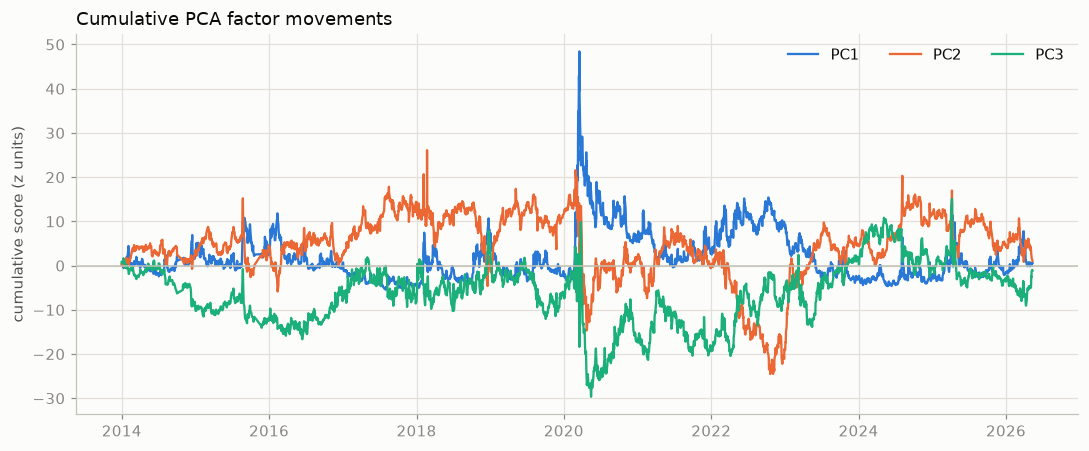

In [5]:
fig, ax = plt.subplots()
for i in range(3):
    z = scores[:, i] / scores[normal][:, i].std()
    ax.plot(book.index, np.cumsum(z), color=PC_C[i], lw=1.5, label=f"PC{i+1}")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative score (z units)")
ax.set_title("Cumulative PCA factor movements", loc="left")
ax.legend(loc="upper right", ncols=3)
plt.tight_layout(); plt.show()

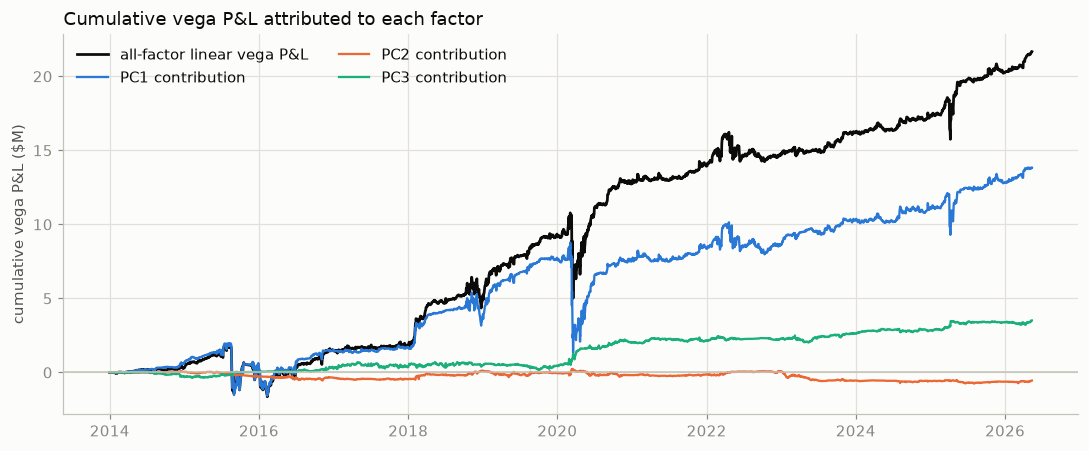

In [6]:
fig, ax = plt.subplots()
lin_total = (bucket_vega * dsigma).sum(axis=1)
ax.plot(book.index, lin_total.cumsum() / 1e6, color=INK, lw=1.8, label="all-factor linear vega P&L")
for i in range(3):
    contrib = exposures[:, i] * scores[:, i]
    ax.plot(book.index, contrib.cumsum() / 1e6, color=PC_C[i], lw=1.5, label=f"PC{i+1} contribution")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative vega P&L ($M)")
ax.set_title("Cumulative vega P&L attributed to each factor", loc="left")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout(); plt.show()

## Daily factor estimate vs full revaluation

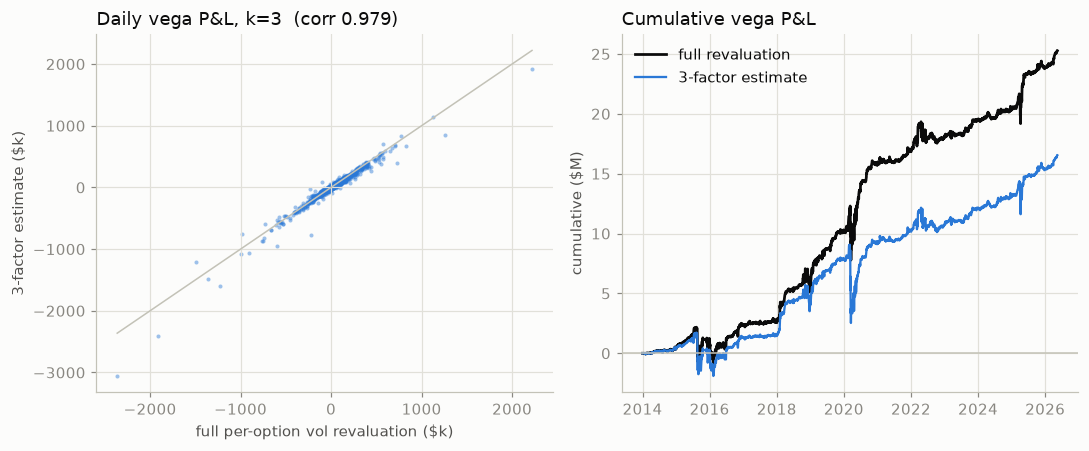

In [7]:
est3 = estimates[3]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
lim = np.array([target[normal].min(), target[normal].max()]) / 1e3
axes[0].plot(lim, lim, color="#c3c2b7", lw=1)
axes[0].scatter(target[normal] / 1e3, est3[normal] / 1e3, s=7, color=PC_C[0], alpha=0.45, lw=0)
c = np.corrcoef(target[normal], est3[normal])[0, 1]
axes[0].set_xlabel("full per-option vol revaluation ($k)")
axes[0].set_ylabel("3-factor estimate ($k)")
axes[0].set_title(f"Daily vega P&L, k=3  (corr {c:.3f})", loc="left")

axes[1].plot(book.index, np.cumsum(target) / 1e6, color=INK, lw=1.8, label="full revaluation")
axes[1].plot(book.index, np.cumsum(est3) / 1e6, color=PC_C[0], lw=1.5, label="3-factor estimate")
axes[1].axhline(0, color="#c3c2b7", lw=1)
axes[1].set_ylabel("cumulative ($M)")
axes[1].set_title("Cumulative vega P&L", loc="left")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

## Reconciling with the attribution notebook's `vol` component

The attribution notebook's `vol` uses the option's **own** implied-vol input change (new
TTM, new moneyness), while the PCA target `pl_vega_full` holds the lookup point fixed.
The two differ by an exact identity (per live leg, full revaluations that telescope):

$$\text{vol} = \underbrace{\text{vol\_surface}}_{\text{= PCA target}}
 + \underbrace{\text{vol\_roll}}_{\text{term-structure roll}}
 + \underbrace{\text{vol\_slide}}_{\text{smile slide (spot-driven)}}$$

**Is the difference an anticipatable carry?** Partly — and the split says exactly which
part. `vol_roll` is knowable in advance: `vol_carry_ex` computes the same roll on the
*previous close's* surface, before the day happens. `vol_slide` is not carry: it is
driven by the day's spot move (it belongs with equity risk — it is the smile-slide term
that the sequential attribution folds into smile delta).

In [8]:
va = attr[["vol", "vol_surface", "vol_roll", "vol_slide", "vol_carry_ex"]]
t = va.loc[normal]
summ = pd.DataFrame({"total ($M)": va.sum() / 1e6,
                     "daily mean ($k)": t.mean() / 1e3,
                     "daily std ($k)": t.std() / 1e3})
print(summ.round(2).to_string())

tele = (va["vol"] - va[["vol_surface", "vol_roll", "vol_slide"]].sum(axis=1)).abs().max()
sdiff = (va["vol_surface"].to_numpy() - target)
print(f"\ntelescope identity max error      : {tele:.2e} $")
print(f"vol_surface vs PCA target         : corr "
      f"{np.corrcoef(va['vol_surface'][normal], target[normal])[0,1]:.6f}, "
      f"max diff {np.abs(sdiff).max():,.0f} $ (settling legs)")
print(f"realized roll vs ex-ante carry    : corr "
      f"{np.corrcoef(t['vol_roll'], t['vol_carry_ex'])[0,1]:.4f}, "
      f"difference std {(t['vol_roll'] - t['vol_carry_ex']).std()/1e3:.1f} $k/day")
sr = book["spot"].pct_change().to_numpy()
m = normal & ~np.isnan(sr)
print(f"slide vs spot return              : corr "
      f"{np.corrcoef(va['vol_slide'][m], sr[m])[0,1]:.3f}  (spot-driven, not carry)")

              total ($M)  daily mean ($k)  daily std ($k)
vol                -2.25            -0.48           69.03
vol_surface        25.29             8.06          148.31
vol_roll          -17.96            -5.73            5.65
vol_slide          -9.58            -2.81          122.38
vol_carry_ex      -18.07            -5.77            5.65

telescope identity max error      : 4.66e-10 $
vol_surface vs PCA target         : corr 1.000000, max diff 2,679 $ (settling legs)
realized roll vs ex-ante carry    : corr 0.9764, difference std 1.2 $k/day
slide vs spot return              : corr -0.620  (spot-driven, not carry)


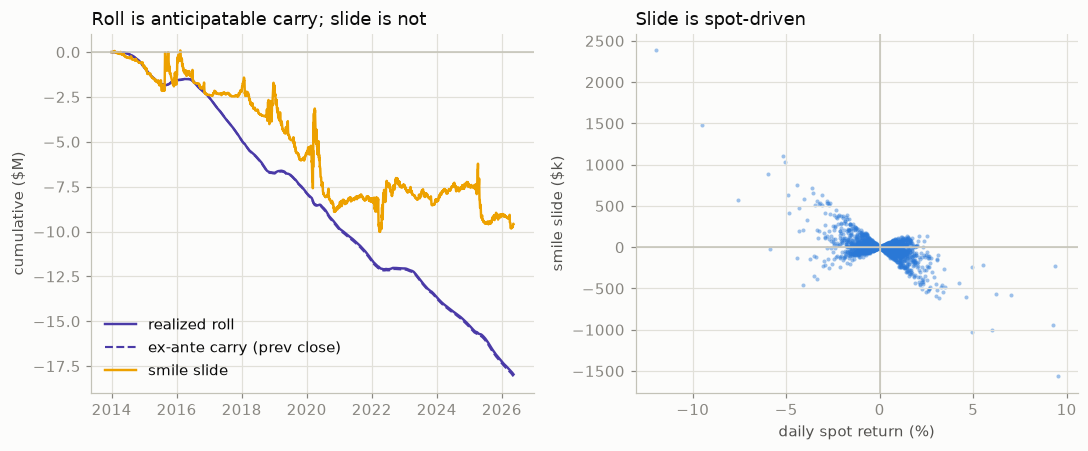

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].plot(attr.index, va["vol_roll"].cumsum() / 1e6, color="#4a3aa7", lw=1.6,
             label="realized roll")
axes[0].plot(attr.index, va["vol_carry_ex"].cumsum() / 1e6, color="#4a3aa7", lw=1.4,
             ls="--", label="ex-ante carry (prev close)")
axes[0].plot(attr.index, va["vol_slide"].cumsum() / 1e6, color="#eda100", lw=1.6,
             label="smile slide")
axes[0].axhline(0, color="#c3c2b7", lw=1)
axes[0].set_ylabel("cumulative ($M)")
axes[0].set_title("Roll is anticipatable carry; slide is not", loc="left")
axes[0].legend(loc="lower left")

axes[1].scatter(sr[m] * 100, va["vol_slide"][m] / 1e3, s=7, color=PC_C[0], alpha=0.45, lw=0)
axes[1].axhline(0, color="#c3c2b7", lw=1); axes[1].axvline(0, color="#c3c2b7", lw=1)
axes[1].set_xlabel("daily spot return (%)")
axes[1].set_ylabel("smile slide ($k)")
axes[1].set_title("Slide is spot-driven", loc="left")
plt.tight_layout(); plt.show()

## Takeaways

- Three vega-weighted factors carry ~99% of dollar-weighted surface variance and
  reproduce the full per-option vol revaluation at corr ≈ 0.98 daily; the all-factor
  linear ceiling (corr 0.996) is vega convexity, not factor truncation.
- Cumulatively the k=3 estimate under-accumulates ≈ \$9M over 12.5y (≈ \$4M vega
  convexity — full vs all-factor linear — plus ≈ \$5M from truncated higher factors):
  a slow drift that matters for carry-style accounting, not for daily-move risk like
  VaR, which is driven by the daily co-movement captured above.
- The attribution `vol` component and the PCA vega target reconcile **exactly**:
  `vol = vol_surface + vol_roll + vol_slide`, with `vol_surface` identical to
  `pl_vega_full`.
- The roll piece **is** an anticipatable carry item — computable from the previous
  close's surface (corr ≈ 0.98 with realized, ~$1k/day noise) and worth ≈ −$18M
  cumulatively for this book.
- The slide piece is **not** carry: it is the day's spot move sliding strikes along the
  smile (corr ≈ −0.6 with spot returns). In risk terms it belongs with (smile) delta,
  which is how the sequential attribution in `book.py` treats it.

Next: historical VaR — full revaluation vs the K-factor estimate on the same book.